# Riesgo postcompra de vehículos en Panamá

## ACODECO 2024–2025 + ADAP 2024–2025

En este notebook fuimos dejando lo que ibamos encontrando poco a poco

Primero revisamos ACODECO para entender bien que datos teniamos
despues revisamos ADAP para ver las ventas por marca

Luego tratamos de unir las dos cosas y ahi fue donde nos dimos cuenta de algo importante

cuando unimos ACODECO con ADAP ya no podemos trabajar una reclamacion por fila
porque ADAP nos da las ventas por marca y por año

entonces nuestra unidad cambia a **marca + año**



## 0. Archivos que vamos a usar

Para que el notebook sea fácil de seguir, trabajamos solamente con:

- `decision-de-quejas-2024.csv`
- `decisionquejas_2025.csv`
- `ADAP_Ventas_Marcas_2025.csv`


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

archivo_2024 = "decision-de-quejas-2024.csv"
archivo_2025 = "decisionquejas_2025.csv"
archivo_adap = "ADAP_Ventas_Marcas_2025.csv"

for archivo in [archivo_2024, archivo_2025, archivo_adap]:
    print(archivo, "->", Path(archivo).exists())


decision-de-quejas-2024.csv -> True
,decisionquejas_2025.csv -> True
,ADAP_Ventas_Marcas_2025.csv -> True


# PARTE A — CONOCER ACODECO

Aquí todavía no pensamos en ADAP ni en el modelo.

Primero queremos saber qué tenemos realmente en los archivos de reclamaciones.


## 1. Cargar 2024 y 2025 por separado


In [2]:
df_2024 = pd.read_csv(
    archivo_2024,
    sep=";",
    encoding="cp850"
)

df_2025 = pd.read_csv(
    archivo_2025,
    sep=";",
    encoding="latin1"
)

print("ACODECO 2024:", df_2024.shape)
print("ACODECO 2025:", df_2025.shape)


ACODECO 2024: (1915, 17)
,ACODECO 2025: (2063, 17)


### Lo que encontramos

- 2024 tiene **1,915 filas y 17 columnas**.
- 2025 tiene **2,063 filas y 17 columnas**.

Antes de unirlos revisamos que realmente tengan la misma estructura.


## 2. Revisar si hay filas completamente vacías


In [3]:
print("Filas totalmente vacías 2024:", df_2024.isna().all(axis=1).sum())
print("Filas totalmente vacías 2025:", df_2025.isna().all(axis=1).sum())


Filas totalmente vacías 2024: 0
,Filas totalmente vacías 2025: 0


No eliminamos filas solo porque tengan algún dato vacío.  
Solamente eliminaríamos una fila si está completamente vacía.


In [4]:
df_2024 = df_2024.dropna(how="all")
df_2025 = df_2025.dropna(how="all")


## 3. Comparar las columnas


In [5]:
print("Mismas columnas:", df_2024.columns.tolist() == df_2025.columns.tolist())

print("\nColumnas:")
for columna in df_2024.columns:
    print("-", columna)


Mismas columnas: True
,
,Columnas:
,- Departamento  de la Institución
,- Provincias dela República  de Panamá
,- Tipo de Ley
,- Fecha de Entrada de Queja
,- Mes de Entrada de Queja
,- Motivo de Queja
,- Agente Económico
,- Actividad
,- Marca de Producto
,- Producto
,- Velor de Apertura de Queja
,- Resultado de Queja
,- Efectivo Devuelto al Consumidor (B/.)
,- Fecha de Cierre de Queja
,- Mes Cierre de Queja
,- Año Cierre de Queja
,- Año Recibido de Queja


### Lo que encontramos

Los dos archivos tienen las mismas 17 columnas y en el mismo orden.

Eso nos permite unirlos sin tener que inventar equivalencias entre columnas.


## 4. Agregar el año y unir los archivos


In [6]:
df_2024["anio"] = 2024
df_2025["anio"] = 2025

acodeco = pd.concat(
    [df_2024, df_2025],
    ignore_index=True
)

print("ACODECO unido:", acodeco.shape)
display(acodeco.head())


ACODECO unido: (3978, 18)


,Departamento de la Institución,Provincias dela República de Panamá,Tipo de Ley,Fecha de Entrada de Queja,Mes de Entrada de Queja,Motivo de Queja,Agente Económico,Actividad,Marca de Producto,Producto,Velor de Apertura de Queja,Resultado de Queja,Efectivo Devuelto al Consumidor (B/.),Fecha de Cierre de Queja,Mes Cierre de Queja,Año Cierre de Queja,Año Recibido de Queja,anio
0,Decisión,Panamá,Ley 45 de 2007,45320,Ene 24,Incumplimiento de garantía,REDPRECIO.COM,Electrodomésticos/equipos electrónicos,HP,Computadora,213.99,Desistimiento/Devolución,213.99,45349.0,Feb 24,2024.0,2024,2024
1,Vehículo a Motor,Panamá,Ley 45 de 2007,45299,Ene 24,Incumplimiento de garantía,BAHIA MOTORS,Agencia de autos,Honda,Auto,775.0,Acuerdo en audiencia/Varios,NaN,45378.0,Mar 24,2024.0,2024,2024
2,Decisión,Panamá,Ley 45 de 2007,45295,Ene 24,Falta de información,"TINO RAMIREZ Y DANIEL, S.A.",Videojuegos,NaN,NaN,840.38,Desistimiento,NaN,45320.0,Ene 24,2024.0,2024,2024
3,Vehículo a Motor,Panamá,Ley 45 de 2007,45301,Ene 24,Incumplimiento de garantía,"GRUPO AUTO COMERCIAL, S.A.",Agencia de autos,GAP,Auto,18750.0,Desistimiento,NaN,45462.0,Jun 24,2024.0,2024,2024
4,Veracidad,Panamá,Ley 45 de 2007,45316,Ene 24,Veracidad de la publicidad,PRICESMART,Supermercados,NaN,NaN,559.99,En proceso,NaN,NaN,NaN,NaN,2024,2024


### Lo que encontramos

Después de unir los dos años tenemos **3,978 reclamaciones**.

Ahora aparecen 18 columnas porque nosotros agregamos `anio` para saber de qué archivo salió cada registro.


## 5. Revisar los departamentos de ACODECO


In [7]:
tabla_departamentos = pd.crosstab(
    acodeco["Departamento  de la Institución"],
    acodeco["anio"]
)

display(tabla_departamentos)


anio,2024,2025
Departamento de la Institución,,
Decisión,1518,1504
Vehículo a Motor,387,537
Veracidad,10,22


### Lo que encontramos

Nuestro proyecto es de vehículos, así que nos interesa el departamento **Vehículo a Motor**:

- 2024: 387 reclamaciones
- 2025: 537 reclamaciones
- Total: **924 reclamaciones**

Todavía no significa que las 924 se puedan comparar con las ventas de autos nuevos de ADAP.


## 6. Quedarnos con Vehículo a Motor


In [8]:
vehiculos = acodeco[
    acodeco["Departamento  de la Institución"] == "Vehículo a Motor"
].copy()

print("Registros de Vehículo a Motor:", vehiculos.shape)
display(vehiculos["anio"].value_counts().sort_index())


Registros de Vehículo a Motor: (924, 18)


anio
2024    387
2025    537
Name: count, dtype: int64

## 6.1 Ver las reclamaciones de Vehículo a Motor por año

Antes de seguir filtrando, hacemos una gráfica sencilla para ver cómo se reparten las reclamaciones entre los dos años.


anio
2024    387
2025    537
Name: count, dtype: int64

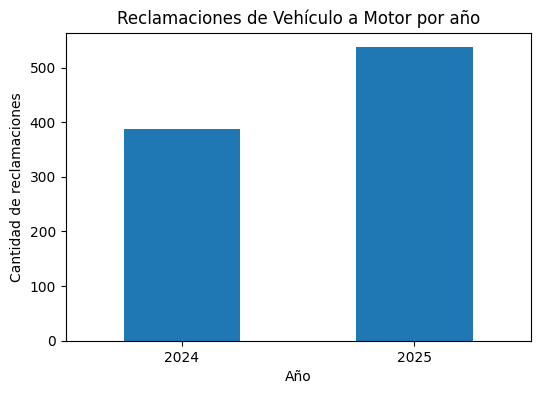

In [9]:
reclamos_por_anio = (
    vehiculos["anio"]
    .value_counts()
    .sort_index()
)

display(reclamos_por_anio)

reclamos_por_anio.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Reclamaciones de Vehículo a Motor por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de reclamaciones")
plt.xticks(rotation=0)
plt.show()


### Lo que vemos

En 2025 aparecen más reclamaciones que en 2024.

Esto solo describe lo que hay en ACODECO. Todavía no significa que el riesgo haya aumentado, porque también puede haber diferencias en ventas, cantidad de vehículos o forma de reportar.


## 7. Revisar las actividades dentro de Vehículo a Motor


In [10]:
display(
    vehiculos["Actividad"]
    .value_counts(dropna=False)
)


Actividad
Agencia de autos                                       332
Venta de autos usados                                  218
Taller de reparación de autos                          159
Repuestos para autos                                   115
Agencia de motos                                        25
Estaciones de gasolinas                                 17
Alquiler de autos                                       16
Servicios de grúas                                       7
Repuestos y reparaciones (talleres varios no autos)      7
Servicios de instalación                                 6
Lavautos                                                 4
Almacén por departamentos                                4
Servicio de intermediación                               3
Ferreterías, materiales de construccion o similares      3
Transporte (fletes, encomiendas y similares)             1
Almacén de ropa y calzados                               1
Envío de dinero                               

### Lo que encontramos

Aquí aparece una diferencia importante.

Dentro de `Vehículo a Motor` no hay solamente compras de autos nuevos. También hay:

- autos usados,
- talleres,
- repuestos,
- motos,
- alquileres,
- gasolineras,
- grúas,
- otros servicios.

Por eso **no podemos dividir las 924 reclamaciones directamente entre las ventas de autos nuevos de ADAP**.


## 8. Separar las actividades que sí son del negocio de autos

Primero hacemos un grupo amplio de actividades de autos. Esto nos sirve para entender mejor el sector antes de aplicar el filtro final.


In [11]:
actividades_autos = [
    "Agencia de autos",
    "Venta de autos usados",
    "Taller de reparación de autos",
    "Repuestos para autos",
    "Alquiler de autos"
]

sector_autos = vehiculos[
    vehiculos["Actividad"].isin(actividades_autos)
].copy()

print("Registros en estas actividades:", len(sector_autos))
display(
    pd.crosstab(
        sector_autos["Actividad"],
        sector_autos["anio"]
    )
)


Registros en estas actividades: 840


anio,2024,2025
Actividad,,
Agencia de autos,149,183
Alquiler de autos,14,2
Repuestos para autos,45,70
Taller de reparación de autos,64,95
Venta de autos usados,81,137


### Lo que encontramos

Después de exigir primero que el registro pertenezca a `Vehículo a Motor`, estas cinco actividades suman **840 reclamaciones**.

Este número es importante porque en una versión anterior aparecían 857. Ese valor incluía 17 registros de otros departamentos que tenían nombres de actividad similares.

Para mantener la trazabilidad, usamos **840** como el grupo amplio de actividades de autos dentro de `Vehículo a Motor`.


## 9. Revisar los productos por año


In [12]:
tabla_productos = pd.crosstab(
    sector_autos["Producto"],
    sector_autos["anio"]
)

display(
    tabla_productos
    .assign(Total=tabla_productos.sum(axis=1))
    .sort_values("Total", ascending=False)
    .head(25)
)


anio,2024,2025,Total
Producto,,,
Automóvil,0,449,449
Auto,316,0,316
Pieza de Repuesto,11,13,24
Batería de auto,4,5,9
No se Registro,0,8,8
Moto,3,4,7
Llanta,2,1,3
Amortiguadores,0,2,2
Transmisión,0,2,2


### Lo que encontramos

El mismo producto aparece escrito diferente según el año:

- en 2024 aparece principalmente `Auto`;
- en 2025 aparece `Automóvil`.

Para poder comparar los años vamos a crear una columna nueva y dejar ambos como `AUTOMOVIL`.


## 10. Crear una versión estándar del producto


In [13]:
sector_autos["producto_std"] = (
    sector_autos["Producto"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({
        "AUTO": "AUTOMOVIL",
        "AUTOMÓVIL": "AUTOMOVIL"
    })
)

display(sector_autos["producto_std"].value_counts(dropna=False).head(20))


producto_std
AUTOMOVIL            765
PIEZA DE REPUESTO     24
<NA>                  16
BATERÍA DE AUTO        9
NO SE REGISTRO         8
MOTO                   7
LLANTA                 3
MOTOR DE AUTO          2
AMORTIGUADORES         2
TRANSMISIÓN            2
#¡NULO!                1
COMPRESOR DE AIRE      1
Name: count, dtype: Int64

## 11. Revisar valores faltantes


In [14]:
nulos = pd.DataFrame({
    "Cantidad": sector_autos.isna().sum(),
    "Porcentaje": (sector_autos.isna().mean() * 100).round(2)
})

display(nulos.sort_values("Porcentaje", ascending=False))


,Cantidad,Porcentaje
Efectivo Devuelto al Consumidor (B/.),832,99.05
Año Cierre de Queja,724,86.19
Fecha de Cierre de Queja,724,86.19
Mes Cierre de Queja,724,86.19
Marca de Producto,54,6.43
producto_std,16,1.90
Producto,16,1.90
Tipo de Ley,0,0.00
Provincias dela República de Panamá,0,0.00
Departamento de la Institución,0,0.00


### Lo que encontramos

Las columnas de cierre y efectivo devuelto tienen muchos faltantes.

Eso no significa necesariamente que el dato esté mal: muchas reclamaciones todavía pueden estar en proceso.

Por ahora no vamos a usar esas columnas para decidir qué registros entran en la unión con ADAP.


## 12. Revisar motivos de queja


In [15]:
display(
    sector_autos["Motivo de Queja"]
    .value_counts(dropna=False)
)


Motivo de Queja
Incumplimiento de garantía    528
Falta de información          106
Incumplimiento de servicio    102
Custodia de bien               44
Devolución de dinero           19
Incumplimiento de contrato     14
Vicio oculto                   12
Daños y perjuicios              5
Cobro indebido                  4
Venta engañosa                  4
Veracidad de la publicidad      1
Mercancía defectuosa            1
Name: count, dtype: int64

### Lo que encontramos

`Incumplimiento de garantía` es el motivo que más aparece.

Más adelante vamos a resumir los motivos por marca y año para usarlos como características del perfil de reclamaciones.


## 13. Revisar marcas


In [16]:
display(
    sector_autos["Marca de Producto"]
    .value_counts(dropna=False)
    .head(40)
)


Marca de Producto
Hyundai           100
Toyota             96
KIA                93
Nissan             75
No se Registro     57
NaN                54
Chevrolet          51
Suzuki             34
Honda              28
Ford               22
Changan            20
Mitsubishi         19
GAC                16
Jetour             15
Mazda              12
Cherry             11
MG                 10
Geely               9
BMW                 8
Kaiyi               8
Audi                7
JEEP                7
Dongfeng            5
Forthing            5
Volkswagen          5
Land Rover          5
Mercedez Benz       5
Peugeot             4
Isuzu               4
Maxus               4
Renault             4
Volvo               4
Karry               3
Fiat                3
Porsche             2
Lexus               2
Subaru              2
Omoda               2
VGV                 2
Chery QQ            2
Name: count, dtype: int64

### Lo que encontramos

Hay marcas bien identificadas, pero también:

- valores vacíos,
- `No se Registro`,
- nombres escritos de forma diferente.

No vamos a borrar la marca original. Crearemos otra columna solamente para hacer el match con ADAP.


## 13.1 Ver las marcas con más reclamaciones

Esta gráfica nos gustaba porque ayuda a ver rápidamente qué marcas aparecen más veces en ACODECO.

Por ahora es solo un conteo. Después veremos cómo cambia la lectura cuando agregamos las ventas de ADAP.


Marca de Producto
Hyundai       100
Toyota         96
KIA            93
Nissan         75
Chevrolet      51
Suzuki         34
Honda          28
Ford           22
Changan        20
Mitsubishi     19
GAC            16
Jetour         15
Mazda          12
Cherry         11
MG             10
Name: count, dtype: int64

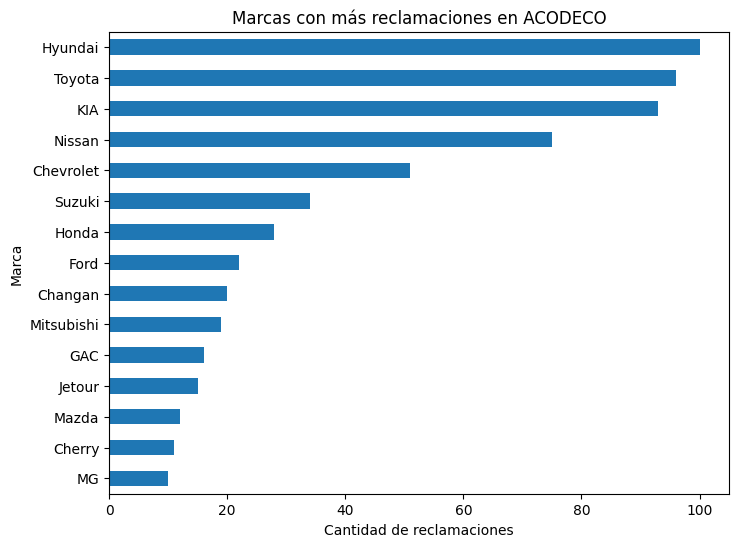

In [17]:
top_marcas_acodeco = (
    sector_autos["Marca de Producto"]
    .dropna()
    .loc[lambda s: s != "No se Registro"]
    .value_counts()
    .head(15)
)

display(top_marcas_acodeco)

top_marcas_acodeco.sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Marcas con más reclamaciones en ACODECO")
plt.xlabel("Cantidad de reclamaciones")
plt.ylabel("Marca")
plt.show()


### Lo que vemos

Hay marcas que aparecen mucho más que otras en cantidad de reclamaciones.

Pero todavía no podemos decir que tengan mayor riesgo. Una marca que vende muchos más vehículos también puede acumular más reclamaciones simplemente por tener mayor presencia en el mercado.

Esta es una de las razones por las que necesitamos ADAP.


## 14. Revisar productos, resultados y provincias


In [18]:
print("PRODUCTOS")
display(sector_autos["Producto"].value_counts(dropna=False).head(20))

print("\nRESULTADOS")
display(sector_autos["Resultado de Queja"].value_counts(dropna=False))

print("\nPROVINCIAS")
display(
    sector_autos["Provincias dela República  de Panamá"]
    .value_counts(dropna=False)
)


PRODUCTOS


Producto
Automóvil            449
Auto                 316
Pieza de Repuesto     24
NaN                   16
Batería de auto        9
No se Registro         8
Moto                   7
Llanta                 3
Motor de Auto          2
Amortiguadores         2
Transmisión            2
#¡NULO!                1
Compresor de aire      1
Name: count, dtype: int64


,RESULTADOS


Resultado de Queja
En proceso                                   724
Desistimiento                                 73
Pendiente constancia desistimiento            14
Acuerdo en audiencia/Devolución de dinero     10
Acuerdo en audiencia/Varios                    7
Inhibe                                         4
Desistimiento/Devolución                       2
Transacción extrajudicial                      2
Abandono                                       1
Ministerio Público                             1
Acuerdo en audiencia/Reparación                1
Inadmitida                                     1
Name: count, dtype: int64


,PROVINCIAS


Provincias dela República  de Panamá
Panamá        695
Pmá Oeste      48
Chiriquí       45
Herrera        21
Veraguas       11
Coclé           8
Los Santos      7
Colón           4
Darién          1
Name: count, dtype: int64

### Lo que encontramos

La mayoría de los resultados todavía aparece como `En proceso`, así que por ahora no vamos a usar el resultado final de la queja como parte central del análisis.

También vemos que la mayoría de las reclamaciones se concentra en Panamá, pero eso por sí solo no significa mayor riesgo.


## 15. Convertir el monto de la queja a número


In [19]:
sector_autos["monto_queja"] = pd.to_numeric(
    sector_autos["Velor de Apertura de Queja"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip(),
    errors="coerce"
)

print("Montos válidos:", sector_autos["monto_queja"].notna().sum())
print("Montos no convertidos:", sector_autos["monto_queja"].isna().sum())

display(sector_autos["monto_queja"].describe().round(2))


Montos válidos: 840
,Montos no convertidos: 0


count      840.00
mean      9459.17
std       9581.73
min          0.00
25%        775.62
50%       5500.00
75%      18495.00
max      30000.00
Name: monto_queja, dtype: float64

# PARTE B — DE ACODECO GENERAL A RECLAMACIONES COMPARABLES CON ADAP

ADAP habla de **vehículos nuevos vendidos por marca**.

Por eso necesitamos una regla clara para no mezclar esas ventas con reclamaciones de talleres, repuestos o autos usados.


## 16. Aplicar el criterio de comparabilidad

Para esta primera integración usamos solamente:

- `Actividad == Agencia de autos`
- `producto_std == AUTOMOVIL`

Este filtro es una decisión del proyecto para acercar ACODECO al concepto de vehículo nuevo vendido por agencia.


In [20]:
reclamos_comparables = sector_autos[
    (sector_autos["Actividad"] == "Agencia de autos")
    & (sector_autos["producto_std"] == "AUTOMOVIL")
].copy()

print("Reclamaciones comparables:", len(reclamos_comparables))
display(
    reclamos_comparables["anio"]
    .value_counts()
    .sort_index()
)


Reclamaciones comparables: 321


anio
2024    144
2025    177
Name: count, dtype: int64

### Lo que encontramos

Quedan **321 reclamaciones comparables**:

- 2024: 144
- 2025: 177

Este es el subconjunto que vamos a intentar relacionar con las ventas de ADAP.


## 17. Preparar las marcas de ACODECO


In [21]:
reclamos_comparables["marca_original"] = (
    reclamos_comparables["Marca de Producto"]
)

reclamos_comparables["marca_std"] = (
    reclamos_comparables["Marca de Producto"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

reclamos_comparables["marca_std"] = reclamos_comparables["marca_std"].replace({
    "NO SE REGISTRO": pd.NA,
    "NO REGISTRADO": pd.NA,
    "#NULO!": pd.NA,
    "CHERRY": "CHERY",
    "CHERY QQ": "CHERY",
    "GAC": "GAC MOTOR",
    "DONGFENG": "DONG FENG",
    "MERCEDEZ BENZ": "MERCEDES BENZ",
    "MINI COOPER": "MINI",
    "IZUZU": "ISUZU"
})

print("Con marca identificada:", reclamos_comparables["marca_std"].notna().sum())

display(
    reclamos_comparables[
        ["marca_original", "marca_std"]
    ]
    .drop_duplicates()
    .sort_values("marca_std")
)


Con marca identificada: 298


,marca_original,marca_std
691,Ava,AVA
2410,Bestune,BESTUNE
1528,BMW,BMW
369,Changan,CHANGAN
3678,Chery QQ,CHERY
543,Cherry,CHERY
117,Chevrolet,CHEVROLET
3804,DFSK,DFSK
530,Dongfeng,DONG FENG
2922,Fiat,FIAT


### Lo que encontramos

De las 321 reclamaciones comparables, **298 tienen una marca identificable**.

Conservamos `marca_original` para poder rastrear cualquier corrección.


# PARTE C — CONOCER ADAP

Ahora dejamos ACODECO a un lado por un momento y revisamos ADAP como una fuente independiente.


## 18. Cargar ADAP


In [22]:
adap_original = pd.read_csv(
    archivo_adap,
    encoding="utf-8-sig"
)

print("ADAP:", adap_original.shape)
display(adap_original.head())


ADAP: (41, 6)


,ranking,marca,total_2025,total_2024,variacion_pct,participacion_pct
0,1.0,TOYOTA,11507,11189.0,2.8,19.1
1,2.0,KIA,7626,7457.0,2.3,12.7
2,3.0,HYUNDAI,6985,7048.0,-0.9,11.6
3,4.0,GEELY,3138,2345.0,33.8,5.2
4,5.0,SUZUKI,3094,2657.0,16.4,5.1


### Lo que encontramos

El archivo tiene **41 filas y 6 columnas**.

No son 41 marcas individuales: hay **40 marcas listadas individualmente + una fila `OTRAS MARCAS`**.


## 19. Revisar columnas, tipos y faltantes


In [23]:
print(adap_original.dtypes)

display(
    pd.DataFrame({
        "Cantidad": adap_original.isna().sum(),
        "Porcentaje": (adap_original.isna().mean() * 100).round(2)
    })
)


ranking              float64
,marca                 object
,total_2025             int64
,total_2024           float64
,variacion_pct        float64
,participacion_pct    float64
,dtype: object


,Cantidad,Porcentaje
ranking,1,2.44
marca,0,0.00
total_2025,0,0.00
total_2024,1,2.44
variacion_pct,1,2.44
participacion_pct,0,0.00


## 20. Validar los totales de ventas


In [24]:
total_2024 = adap_original["total_2024"].sum(skipna=True)
total_2025 = adap_original["total_2025"].sum(skipna=True)

print("Ventas 2024:", int(total_2024))
print("Ventas 2025:", int(total_2025))
print(
    "Crecimiento:",
    round((total_2025 - total_2024) / total_2024 * 100, 2),
    "%"
)


Ventas 2024: 54384
,Ventas 2025: 60233
,Crecimiento: 10.76 %


### Lo que encontramos

- 2024: **54,384 vehículos**
- 2025: **60,233 vehículos**
- Crecimiento aproximado: **10.76%**

Esto confirma que el tamaño del mercado cambia entre años.


## 21. Revisar las marcas con más ventas


In [25]:
print("2024")
display(
    adap_original[
        ["marca", "total_2024"]
    ]
    .sort_values("total_2024", ascending=False)
    .head(12)
)

print("\n2025")
display(
    adap_original[
        ["marca", "total_2025"]
    ]
    .sort_values("total_2025", ascending=False)
    .head(12)
)


2024


,marca,total_2024
0,TOYOTA,11189.0
1,KIA,7457.0
2,HYUNDAI,7048.0
4,SUZUKI,2657.0
6,NISSAN,2417.0
3,GEELY,2345.0
5,MITSUBISHI,2233.0
8,CHANGAN,1736.0
9,ISUZU,1584.0
40,OTRAS MARCAS,1552.0



,2025


,marca,total_2025
0,TOYOTA,11507
1,KIA,7626
2,HYUNDAI,6985
3,GEELY,3138
4,SUZUKI,3094
5,MITSUBISHI,2185
6,NISSAN,2166
7,JETOUR,1999
8,CHANGAN,1854
9,ISUZU,1747


### Lo que encontramos

Toyota, KIA y Hyundai aparecen entre las marcas con más ventas.

Esto refuerza la idea del proyecto: **un número alto de reclamaciones no se puede interpretar igual para una marca que vende 10,000 vehículos que para otra que vende 300**.


## 21.1 Comparar visualmente las ventas 2024 y 2025

Tomamos las principales marcas por ventas de 2025 y las comparamos con 2024.


,marca,total_2024,total_2025
0,TOYOTA,11189.0,11507
1,KIA,7457.0,7626
2,HYUNDAI,7048.0,6985
3,GEELY,2345.0,3138
4,SUZUKI,2657.0,3094
5,MITSUBISHI,2233.0,2185
6,NISSAN,2417.0,2166
7,JETOUR,1264.0,1999
8,CHANGAN,1736.0,1854
9,ISUZU,1584.0,1747


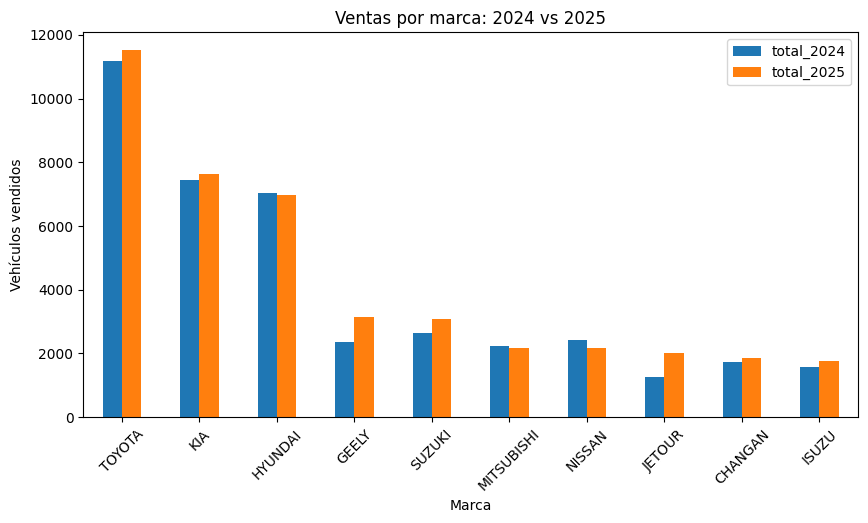

In [26]:
top10_adap = (
    adap_original[
        adap_original["marca"] != "OTRAS MARCAS"
    ]
    .sort_values("total_2025", ascending=False)
    .head(10)
)

display(
    top10_adap[
        ["marca", "total_2024", "total_2025"]
    ]
)

top10_adap[
    ["marca", "total_2024", "total_2025"]
].set_index("marca").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ventas por marca: 2024 vs 2025")
plt.xlabel("Marca")
plt.ylabel("Vehículos vendidos")
plt.xticks(rotation=45)
plt.show()


### Lo que vemos

Las diferencias de volumen entre marcas son grandes.

Esto confirma que mirar solamente el número de reclamaciones puede ser engañoso. Necesitamos poner ese conteo en relación con las ventas.


## 22. Pasar ADAP al formato año + marca + ventas


In [27]:
adap = (
    adap_original[
        ["marca", "total_2024", "total_2025"]
    ]
    .melt(
        id_vars="marca",
        value_vars=["total_2024", "total_2025"],
        var_name="anio",
        value_name="ventas"
    )
)

adap["anio"] = (
    adap["anio"]
    .str.replace("total_", "", regex=False)
    .astype(int)
)

adap["marca_std"] = (
    adap["marca"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

display(adap.head(10))


,marca,anio,ventas,marca_std
0,TOYOTA,2024,11189.0,TOYOTA
1,KIA,2024,7457.0,KIA
2,HYUNDAI,2024,7048.0,HYUNDAI
3,GEELY,2024,2345.0,GEELY
4,SUZUKI,2024,2657.0,SUZUKI
5,MITSUBISHI,2024,2233.0,MITSUBISHI
6,NISSAN,2024,2417.0,NISSAN
7,JETOUR,2024,1264.0,JETOUR
8,CHANGAN,2024,1736.0,CHANGAN
9,ISUZU,2024,1584.0,ISUZU


# PARTE D — COMPROBAR SI LAS MARCAS COINCIDEN

Antes de hacer un `merge`, comprobamos qué tanto coincide ACODECO con ADAP.


## 23. Revisar el match de marcas


In [28]:
marcas_adap = set(
    adap.loc[
        adap["marca_std"] != "OTRAS MARCAS",
        "marca_std"
    ].dropna()
)

reclamos_comparables["coincide_adap"] = (
    reclamos_comparables["marca_std"].isin(marcas_adap)
)

total_comparable = len(reclamos_comparables)
identificables = reclamos_comparables["marca_std"].notna().sum()
con_match = reclamos_comparables["coincide_adap"].sum()

print("Reclamaciones comparables:", total_comparable)
print("Con marca identificable:", identificables)
print("Con match en ADAP:", con_match)
print("Cobertura sobre el total:", round(con_match / total_comparable * 100, 2), "%")
print("Cobertura entre las identificables:", round(con_match / identificables * 100, 2), "%")


Reclamaciones comparables: 321
,Con marca identificable: 298
,Con match en ADAP: 274
,Cobertura sobre el total: 85.36 %
,Cobertura entre las identificables: 91.95 %


### Lo que encontramos

- 321 reclamaciones comparables
- 298 con marca identificable
- 274 con match individual en ADAP
- cobertura total: **85.36%**
- cobertura entre las que sí tienen marca: aproximadamente **91.95%**

La unión sí es viable, aunque no cubre todos los registros.


## 24. Ver qué no logró coincidir


In [29]:
sin_match = (
    reclamos_comparables.loc[
        ~reclamos_comparables["coincide_adap"],
        "marca_std"
    ]
    .value_counts(dropna=False)
)

display(sin_match)


marca_std
<NA>       23
JEEP        5
PEUGEOT     3
KARRY       3
FIAT        2
VGV         2
YEMA        1
AVA         1
MINI        1
GAP         1
POER        1
BESTUNE     1
RAM         1
HAVAL       1
DFSK        1
Name: count, dtype: Int64

### Decisión

No vamos a forzar esas marcas dentro de `OTRAS MARCAS`.

Si ADAP no nos da una venta individual para una marca, no inventamos el denominador.


# PARTE E — PONER ACODECO Y ADAP EN LA MISMA UNIDAD

ADAP tiene una fila por **marca y año**.

Entonces ACODECO también debe resumirse a **marca y año** antes de hacer la unión.


## 25. Crear variables útiles de ACODECO por marca-año


In [30]:
reclamos_match = reclamos_comparables[
    reclamos_comparables["coincide_adap"]
].copy()

reclamos_match["monto_queja"] = pd.to_numeric(
    reclamos_match["Velor de Apertura de Queja"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip(),
    errors="coerce"
)

reclamos_match["es_garantia"] = (
    reclamos_match["Motivo de Queja"] == "Incumplimiento de garantía"
).astype(int)

reclamos_match["es_servicio"] = (
    reclamos_match["Motivo de Queja"] == "Incumplimiento de servicio"
).astype(int)

reclamos_match["es_falta_info"] = (
    reclamos_match["Motivo de Queja"] == "Falta de información"
).astype(int)

resumen_acodeco = (
    reclamos_match
    .groupby(["anio", "marca_std"])
    .agg(
        cantidad_quejas=("marca_std", "size"),
        monto_promedio=("monto_queja", "mean"),
        monto_mediano=("monto_queja", "median"),
        pct_garantia=("es_garantia", "mean"),
        pct_servicio=("es_servicio", "mean"),
        pct_falta_info=("es_falta_info", "mean"),
        motivos_distintos=("Motivo de Queja", "nunique")
    )
    .reset_index()
)

for columna in ["pct_garantia", "pct_servicio", "pct_falta_info"]:
    resumen_acodeco[columna] = resumen_acodeco[columna] * 100

display(resumen_acodeco.head(15).round(2))


,anio,marca_std,cantidad_quejas,monto_promedio,monto_mediano,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos
0,2024,BMW,1,851.34,851.34,100.00,0.00,0.0,1
1,2024,CHANGAN,6,20288.17,20488.50,100.00,0.00,0.0,1
2,2024,CHERY,3,19730.00,17300.00,100.00,0.00,0.0,1
3,2024,CHEVROLET,22,18044.28,18527.50,81.82,13.64,0.0,3
4,2024,DONG FENG,2,22500.00,22500.00,100.00,0.00,0.0,1
5,2024,FORD,2,269.69,269.69,50.00,50.00,0.0,2
6,2024,FORTHING,5,23366.02,23240.00,100.00,0.00,0.0,1
7,2024,GAC MOTOR,6,19050.00,18175.00,100.00,0.00,0.0,1
8,2024,GEELY,3,16932.63,24500.00,100.00,0.00,0.0,1
9,2024,HONDA,3,4216.75,775.00,100.00,0.00,0.0,1


### Qué significa esta tabla

Cada fila ya representa una combinación `marca-año`.

Además de contar reclamaciones, resumimos algunas características que después pueden servir para entender el perfil de esas reclamaciones:

- monto promedio,
- monto mediano,
- porcentaje por garantía,
- porcentaje por incumplimiento de servicio,
- porcentaje por falta de información,
- cantidad de motivos distintos.


## 26. Preparar ADAP a la misma unidad


In [31]:
adap_anual = (
    adap[
        (adap["marca_std"] != "OTRAS MARCAS")
        & adap["ventas"].notna()
    ][["anio", "marca_std", "ventas"]]
    .copy()
)

display(adap_anual.head(15))


,anio,marca_std,ventas
0,2024,TOYOTA,11189.0
1,2024,KIA,7457.0
2,2024,HYUNDAI,7048.0
3,2024,GEELY,2345.0
4,2024,SUZUKI,2657.0
5,2024,MITSUBISHI,2233.0
6,2024,NISSAN,2417.0
7,2024,JETOUR,1264.0
8,2024,CHANGAN,1736.0
9,2024,ISUZU,1584.0


# PARTE F — HACER LA UNIÓN

Ahora sí ambas tablas están en `marca + año`.


## 27. Unir ACODECO con ADAP


In [32]:
dataset_integrado = resumen_acodeco.merge(
    adap_anual,
    on=["anio", "marca_std"],
    how="inner"
)

print("Combinaciones marca-año:", len(dataset_integrado))
display(
    dataset_integrado
    .sort_values(["anio", "cantidad_quejas"], ascending=[True, False])
    .head(30)
    .round(2)
)


Combinaciones marca-año: 44


,anio,marca_std,cantidad_quejas,monto_promedio,monto_mediano,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos,ventas
3,2024,CHEVROLET,22,18044.28,18527.50,81.82,13.64,0.00,3,426.0
13,2024,KIA,18,14534.87,15022.50,94.44,0.00,0.00,2,7457.0
19,2024,TOYOTA,15,19147.66,20500.00,73.33,6.67,13.33,4,11189.0
10,2024,HYUNDAI,10,13472.66,15099.00,80.00,20.00,0.00,2,7048.0
17,2024,NISSAN,7,23239.81,28000.00,71.43,14.29,0.00,3,2417.0
18,2024,SUZUKI,7,12771.32,14740.00,85.71,14.29,0.00,2,2657.0
1,2024,CHANGAN,6,20288.17,20488.50,100.00,0.00,0.00,1,1736.0
7,2024,GAC MOTOR,6,19050.00,18175.00,100.00,0.00,0.00,1,1129.0
6,2024,FORTHING,5,23366.02,23240.00,100.00,0.00,0.00,1,727.0
16,2024,MITSUBISHI,4,7111.04,1186.53,50.00,0.00,25.00,3,2233.0


### Lo que encontramos

Después de poner ACODECO y ADAP al mismo nivel, obtenemos **44 combinaciones marca-año**.

A partir de este punto, estas 44 filas pasan a ser nuestro **conjunto de trabajo para el modelo**.

Cada fila representa una combinación real de una marca en un año determinado.

Por ejemplo:

- TOYOTA - 2024
- TOYOTA - 2025
- KIA - 2024
- KIA - 2025

Ya no estamos trabajando con reclamaciones individuales, sino con el resumen de cada marca-año junto con sus ventas y las características de sus reclamaciones.


## 27.1 Por que nuestro conjunto para el modelo tiene 44 filas

Este punto nos costo entenderlo al principio asi que lo dejamos explicado

empezamos con reclamaciones individuales de ACODECO

pero ADAP no tiene una fila por reclamacion
ADAP tiene las ventas por **marca y año**

entonces para unir las dos fuentes tenemos que poner ACODECO al mismo nivel

por ejemplo si tenemos varias reclamaciones de Toyota en 2025
las resumimos en una sola fila Toyota 2025

ahi guardamos cuantas reclamaciones tuvo esa marca ese año
el monto promedio
los motivos que aparecen
y luego le agregamos las ventas de ADAP

al hacer eso nos quedan

- 21 combinaciones marca-año en 2024
- 23 combinaciones marca-año en 2025
- **44 combinaciones en total**
- 27 marcas diferentes
- 17 marcas aparecen en los dos años
- 10 aparecen solo en uno

estas **44 observaciones son las que usamos para el modelo**

preferimos quedarnos con esas 44 filas reales
antes que repetir el mismo dato de ventas muchas veces solo para que parezca que tenemos mas registros


In [33]:
print("Filas marca-año:", len(dataset_integrado))
print("Marcas diferentes:", dataset_integrado["marca_std"].nunique())

apariciones_por_marca = (
    dataset_integrado
    .groupby("marca_std")["anio"]
    .nunique()
)

print(
    "Marcas presentes en ambos años:",
    (apariciones_por_marca == 2).sum()
)

print(
    "Marcas presentes en un solo año:",
    (apariciones_por_marca == 1).sum()
)

display(
    dataset_integrado
    .groupby("anio")
    .size()
    .rename("combinaciones_marca_anio")
)


Filas marca-año: 44
,Marcas diferentes: 27
,Marcas presentes en ambos años: 17
,Marcas presentes en un solo año: 10


anio
2024    21
2025    23
Name: combinaciones_marca_anio, dtype: int64

## 27.2 Como pasamos de 274 reclamaciones a las 44 observaciones del modelo

Las 274 filas todavia son reclamaciones individuales

por ejemplo podemos tener

- Toyota 2025 reclamacion 1
- Toyota 2025 reclamacion 2
- Toyota 2025 reclamacion 3

pero para Toyota 2025 ADAP tiene un solo valor de ventas

entonces todas esas reclamaciones se juntan en una sola observacion

`Toyota + 2025`

en esa fila guardamos por ejemplo

- cantidad de reclamaciones
- monto promedio
- monto mediano
- porcentaje de garantia
- porcentaje de servicio
- cantidad de motivos diferentes
- ventas de ese año

hacemos lo mismo con todas las marcas y años

asi las 274 reclamaciones no desaparecen
quedan resumidas dentro de las **44 observaciones marca-año**


In [34]:
print("Reclamaciones individuales con match:", len(reclamos_match))
print("Combinaciones marca-año antes de unir con ADAP:", len(resumen_acodeco))
print("Combinaciones finales con ventas:", len(dataset_integrado))


Reclamaciones individuales con match: 274
,Combinaciones marca-año antes de unir con ADAP: 44
,Combinaciones finales con ventas: 44


### Resultado

- 274 reclamaciones individuales logran hacer match con ADAP.
- esas reclamaciones se agrupan por `marca + año`;
- el resultado final son **44 combinaciones marca-año**.

Desde este punto, esas **44 filas son nuestro dataset para el modelo**.

Toda la creación del riesgo, las gráficas posteriores y las pruebas de clasificación se hacen sobre esas 44 observaciones.


## 27.3 Ver exactamente cuáles son las 44 combinaciones

Aquí mostramos todas las filas finales para que quede claro qué representa cada observación.


In [35]:
combinaciones_44 = (
    dataset_integrado[
        [
            "anio",
            "marca_std",
            "cantidad_quejas",
            "ventas",
            "monto_promedio",
            "monto_mediano",
            "pct_garantia",
            "pct_servicio",
            "pct_falta_info",
            "motivos_distintos"
        ]
    ]
    .sort_values(["anio", "marca_std"])
    .reset_index(drop=True)
)

display(combinaciones_44)


,anio,marca_std,cantidad_quejas,ventas,monto_promedio,monto_mediano,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos
0,2024,BMW,1,532.0,851.340000,851.340,100.000000,0.000000,0.000000,1
1,2024,CHANGAN,6,1736.0,20288.166667,20488.500,100.000000,0.000000,0.000000,1
2,2024,CHERY,3,509.0,19730.000000,17300.000,100.000000,0.000000,0.000000,1
3,2024,CHEVROLET,22,426.0,18044.279091,18527.500,81.818182,13.636364,0.000000,3
4,2024,DONG FENG,2,931.0,22500.000000,22500.000,100.000000,0.000000,0.000000,1
5,2024,FORD,2,1299.0,269.690000,269.690,50.000000,50.000000,0.000000,2
6,2024,FORTHING,5,727.0,23366.020000,23240.000,100.000000,0.000000,0.000000,1
7,2024,GAC MOTOR,6,1129.0,19049.998333,18175.000,100.000000,0.000000,0.000000,1
8,2024,GEELY,3,2345.0,16932.626667,24500.000,100.000000,0.000000,0.000000,1
9,2024,HONDA,3,1218.0,4216.746667,775.000,100.000000,0.000000,0.000000,1


### Cómo leer esta tabla

Cada fila representa una sola combinación `marca-año`.

Ejemplo:

- TOYOTA - 2024
- TOYOTA - 2025
- KIA - 2024
- KIA - 2025

Algunas marcas aparecen en los dos años y otras solamente en uno.

Por eso no hacemos `27 marcas × 2 años = 54` automáticamente.  
Solo contamos las combinaciones que realmente existen después de la unión.


### A partir de aquí cambia el nivel del análisis

Hasta esta parte usamos las reclamaciones individuales para explorar y construir la información.

Desde ahora trabajamos con las **44 combinaciones marca-año**.

Eso quiere decir que:

- el nivel de riesgo se crea sobre estas 44 filas;
- los gráficos del análisis integrado usan estas 44 filas;
- las variables del modelo salen de estas 44 filas;
- la validación del modelo se hace con estas 44 filas.

Así mantenemos una sola unidad de análisis y evitamos mezclar reclamaciones individuales con datos de ventas anuales.


## 28. Confirmar que tenemos ventas válidas


In [36]:
print("Ventas faltantes:", dataset_integrado["ventas"].isna().sum())
print("Ventas iguales a cero:", (dataset_integrado["ventas"] == 0).sum())


Ventas faltantes: 0
,Ventas iguales a cero: 0


## 28.1 Revisar qué marcas aparecen en ambos años

Esto también nos ayuda a entender las 44 filas.


In [37]:
presencia_marcas = (
    dataset_integrado
    .groupby("marca_std")["anio"]
    .agg(["nunique", "min", "max"])
    .rename(columns={
        "nunique": "cantidad_anios",
        "min": "primer_anio",
        "max": "ultimo_anio"
    })
    .sort_values(["cantidad_anios", "primer_anio"], ascending=[False, True])
)

display(presencia_marcas)

print("Marcas en ambos años:", (presencia_marcas["cantidad_anios"] == 2).sum())
print("Marcas en un solo año:", (presencia_marcas["cantidad_anios"] == 1).sum())


,cantidad_anios,primer_anio,ultimo_anio
marca_std,,,
CHANGAN,2,2024,2025
CHERY,2,2024,2025
CHEVROLET,2,2024,2025
DONG FENG,2,2024,2025
FORD,2,2024,2025
GAC MOTOR,2,2024,2025
GEELY,2,2024,2025
HONDA,2,2024,2025
HYUNDAI,2,2024,2025


Marcas en ambos años: 17
,Marcas en un solo año: 10


### Lo que vemos

Tenemos **27 marcas distintas**:

- 17 aparecen en 2024 y 2025
- 10 aparecen solamente en uno de los dos años

Eso explica por qué terminamos con **44 combinaciones** y no con 54.


# PARTE G — NORMALIZAR LAS RECLAMACIONES

Aquí aparece la parte central de la idea del proyecto.


## 29. Calcular reclamaciones observadas por cada 1,000 ventas


In [38]:
dataset_integrado["reclamos_por_1000_ventas"] = (
    dataset_integrado["cantidad_quejas"]
    / dataset_integrado["ventas"]
    * 1000
)

display(
    dataset_integrado[
        [
            "anio",
            "marca_std",
            "cantidad_quejas",
            "ventas",
            "reclamos_por_1000_ventas"
        ]
    ]
    .sort_values(
        ["anio", "reclamos_por_1000_ventas"],
        ascending=[True, False]
    )
    .round(2)
)


,anio,marca_std,cantidad_quejas,ventas,reclamos_por_1000_ventas
3,2024,CHEVROLET,22,426.0,51.64
6,2024,FORTHING,5,727.0,6.88
15,2024,MG,3,456.0,6.58
2,2024,CHERY,3,509.0,5.89
7,2024,GAC MOTOR,6,1129.0,5.31
12,2024,JAC,1,235.0,4.26
1,2024,CHANGAN,6,1736.0,3.46
20,2024,VOLKSWAGEN,1,335.0,2.99
17,2024,NISSAN,7,2417.0,2.90
18,2024,SUZUKI,7,2657.0,2.63


### Cómo lo interpretamos

No estamos diciendo que esto sea una tasa oficial de fallas.

Lo usamos como un indicador para poner las reclamaciones en contexto con el volumen de ventas del mismo año.

Así podemos comparar mejor una marca grande con una marca pequeña.


## 29.1 Ver ventas y reclamaciones juntas

Antes de mirar el indicador por 1,000 ventas, hacemos una gráfica para entender por qué necesitamos normalizar.

Cada punto representa una combinación marca-año.


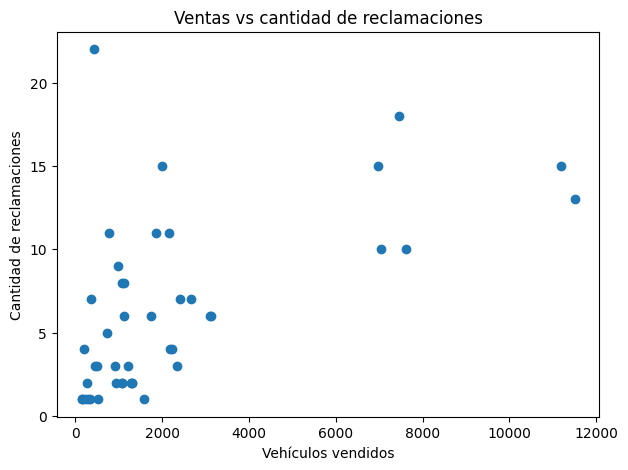

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dataset_integrado["ventas"],
    dataset_integrado["cantidad_quejas"]
)

plt.title("Ventas vs cantidad de reclamaciones")
plt.xlabel("Vehículos vendidos")
plt.ylabel("Cantidad de reclamaciones")
plt.show()


### Lo que vemos

Las marcas no están expuestas al mismo volumen de ventas.

Por eso una marca con más reclamaciones no necesariamente tiene una relación reclamaciones/ventas más alta.

El siguiente paso es justamente calcular esa relación de una forma comparable.


## 30. Revisar la distribución del indicador


count    44.00
mean      5.66
std       8.28
min       0.63
25%       1.85
50%       2.94
75%       6.65
max      51.64
Name: reclamos_por_1000_ventas, dtype: float64

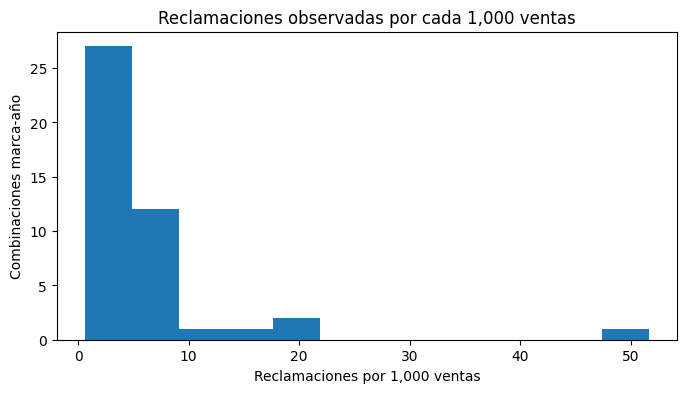

In [40]:
display(
    dataset_integrado["reclamos_por_1000_ventas"]
    .describe()
    .round(2)
)

plt.figure(figsize=(8, 4))
plt.hist(
    dataset_integrado["reclamos_por_1000_ventas"],
    bins=12
)
plt.title("Reclamaciones observadas por cada 1,000 ventas")
plt.xlabel("Reclamaciones por 1,000 ventas")
plt.ylabel("Combinaciones marca-año")
plt.show()


### Lo que encontramos

La distribución tiene algunos valores altos.

Por eso no escogemos límites manuales. Vamos a usar la propia distribución para formar tres grupos.


## 30.1 Ver las combinaciones marca-año con mayor indicador

Aquí ya usamos las reclamaciones por cada 1,000 ventas.

No lo mostramos como una lista de "mejores" o "peores" marcas. Solo queremos ver cuáles combinaciones marca-año tienen los valores más altos dentro de nuestros datos.


,anio,marca_std,reclamos_por_1000_ventas,marca_anio
3,2024,CHEVROLET,51.64,CHEVROLET - 2024
36,2025,MG,19.66,MG - 2025
34,2025,MAXUS,19.05,MAXUS - 2025
23,2025,CHEVROLET,14.10,CHEVROLET - 2025
22,2025,CHERY,9.25,CHERY - 2025
31,2025,KAIYI,7.50,KAIYI - 2025
30,2025,JETOUR,7.50,JETOUR - 2025
39,2025,OMODA,7.19,OMODA - 2025
26,2025,GAC MOTOR,7.10,GAC MOTOR - 2025
43,2025,VOLVO,6.90,VOLVO - 2025


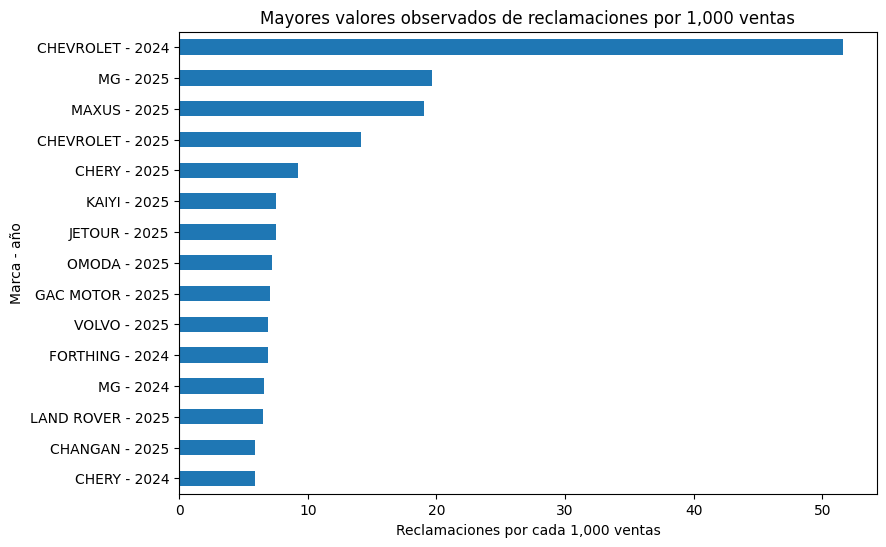

In [41]:
top_indicador = (
    dataset_integrado[
        [
            "anio",
            "marca_std",
            "reclamos_por_1000_ventas"
        ]
    ]
    .assign(
        marca_anio=lambda x:
            x["marca_std"] + " - " + x["anio"].astype(str)
    )
    .sort_values(
        "reclamos_por_1000_ventas",
        ascending=False
    )
    .head(15)
)

display(top_indicador.round(2))

top_indicador.sort_values(
    "reclamos_por_1000_ventas"
).plot(
    x="marca_anio",
    y="reclamos_por_1000_ventas",
    kind="barh",
    figsize=(9, 6),
    legend=False
)

plt.title("Mayores valores observados de reclamaciones por 1,000 ventas")
plt.xlabel("Reclamaciones por cada 1,000 ventas")
plt.ylabel("Marca - año")
plt.show()


### Lo que vemos

Cuando usamos el indicador normalizado, el orden cambia respecto al simple conteo de reclamaciones.

Eso es justamente lo que queríamos comprobar con la unión de ACODECO y ADAP: el volumen de ventas cambia la forma de interpretar las reclamaciones.


# PARTE H — CREAR EL NIVEL DE RIESGO RELATIVO

Usamos terciles:

- tercio inferior → Bajo
- tercio central → Medio
- tercio superior → Alto

Esto significa que el riesgo es **relativo al grupo que estamos analizando**.


## 31. Calcular los cortes


In [42]:
corte_bajo = dataset_integrado[
    "reclamos_por_1000_ventas"
].quantile(1/3)

corte_alto = dataset_integrado[
    "reclamos_por_1000_ventas"
].quantile(2/3)

print("Corte Bajo/Medio:", round(corte_bajo, 2))
print("Corte Medio/Alto:", round(corte_alto, 2))


Corte Bajo/Medio: 1.92
,Corte Medio/Alto: 5.7


Con los datos actuales los cortes quedan aproximadamente en:

- Bajo: hasta **1.92**
- Medio: más de **1.92** y hasta **5.70**
- Alto: más de **5.70**

Estos valores no son límites oficiales. Salen de nuestros datos.


## 32. Crear la variable objetivo


In [43]:
dataset_integrado["Nivel_Riesgo_Relativo"] = pd.qcut(
    dataset_integrado["reclamos_por_1000_ventas"],
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

display(
    dataset_integrado[
        [
            "anio",
            "marca_std",
            "cantidad_quejas",
            "ventas",
            "reclamos_por_1000_ventas",
            "Nivel_Riesgo_Relativo"
        ]
    ]
    .sort_values("reclamos_por_1000_ventas")
    .round(2)
)


,anio,marca_std,cantidad_quejas,ventas,reclamos_por_1000_ventas,Nivel_Riesgo_Relativo
11,2024,ISUZU,1,1584.0,0.63,Bajo
41,2025,TOYOTA,13,11507.0,1.13,Bajo
8,2024,GEELY,3,2345.0,1.28,Bajo
32,2025,KIA,10,7626.0,1.31,Bajo
19,2024,TOYOTA,15,11189.0,1.34,Bajo
10,2024,HYUNDAI,10,7048.0,1.42,Bajo
25,2025,FORD,2,1315.0,1.52,Bajo
5,2024,FORD,2,1299.0,1.54,Bajo
35,2025,MAZDA,2,1275.0,1.57,Bajo
16,2024,MITSUBISHI,4,2233.0,1.79,Bajo


## 33. Ver cuántos quedaron en cada grupo


Nivel_Riesgo_Relativo
Bajo     15
Medio    14
Alto     15
Name: count, dtype: int64

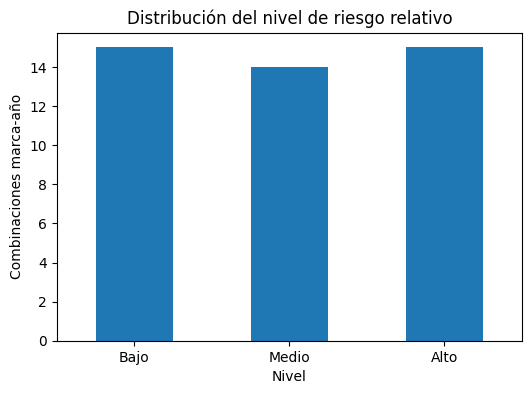

In [44]:
orden_riesgo = ["Bajo", "Medio", "Alto"]

conteo_riesgo = (
    dataset_integrado["Nivel_Riesgo_Relativo"]
    .value_counts()
    .reindex(orden_riesgo)
)

display(conteo_riesgo)

conteo_riesgo.plot(kind="bar", figsize=(6, 4))
plt.title("Distribución del nivel de riesgo relativo")
plt.xlabel("Nivel")
plt.ylabel("Combinaciones marca-año")
plt.xticks(rotation=0)
plt.show()


### Lo que encontramos

Quedan:

- Bajo: 15
- Medio: 14
- Alto: 15

La variable objetivo queda bastante equilibrada.


## 34. Comparar una misma marca entre 2024 y 2025

Una marca no tiene que quedar siempre en la misma categoría. El nivel se calcula por año.


In [45]:
comparacion_anual = dataset_integrado.pivot_table(
    index="marca_std",
    columns="anio",
    values=[
        "reclamos_por_1000_ventas",
        "Nivel_Riesgo_Relativo"
    ],
    aggfunc="first"
)

display(comparacion_anual)


Nivel_Riesgo_Relativo        reclamos_por_1000_ventas           
anio                        2024   2025                     2024       2025
marca_std                                                                  
BMW                         Bajo    NaN                 1.879699        NaN
CHANGAN                    Medio   Alto                 3.456221   5.933118
CHERY                       Alto   Alto                 5.893910   9.249743
CHEVROLET                   Alto   Alto                51.643192  14.102564
DONG FENG                  Medio  Medio                 2.148228   3.311258
FORD                        Bajo   Bajo                 1.539646   1.520913
FORTHING                    Alto    NaN                 6.877579        NaN
GAC MOTOR                  Medio   Alto                 5.314438   7.098492
GEELY                       Bajo   Bajo                 1.279318   1.912046
HONDA                      Medio   Bajo                 2.463054   1.860465
HYUNDAI                     Bajo  Medio                 1.418842   2.147459
ISUZU                       Bajo    NaN                 0.631313        NaN
JAC                        Medio    NaN                 4.255319        NaN
JETOUR                       NaN   Alto                      NaN   7.503752
KAIYI                        NaN   Alto                      NaN   7.504690
KIA                        Medio   Bajo                 2.413839   1.311303
LAND ROVER                   NaN   Alto                      NaN   6.493506
MAXUS                        NaN   Alto                      NaN  19.047619
MAZDA                       Bajo   Bajo                 1.857010   1.568627
MG                          Alto   Alto                 6.578947  19.662921
MITSUBISHI                  Bajo   Bajo                 1.791312   1.830664
NISSAN                     Medio  Medio                 2.896152   5.078486
OMODA                        NaN   Alto                      NaN   7.194245
SUZUKI                     Medio  Medio                 2.634550   1.939237
TOYOTA                      Bajo   Bajo                 1.340602   1.129747
VOLKSWAGEN                 Medio  Medio                 2.985075   3.311258
VOLVO                        NaN   Alto                      NaN   6.896552

## 34.1 Comparar 2024 y 2025 en las marcas que aparecen en ambos años

Para que la comparación sea más justa, aquí mostramos solamente marcas que tienen información integrada en los dos años.


anio,2024,2025
marca_std,,
MG,6.58,19.66
CHEVROLET,51.64,14.10
CHERY,5.89,9.25
GAC MOTOR,5.31,7.10
CHANGAN,3.46,5.93
NISSAN,2.90,5.08
VOLKSWAGEN,2.99,3.31
DONG FENG,2.15,3.31
HYUNDAI,1.42,2.15


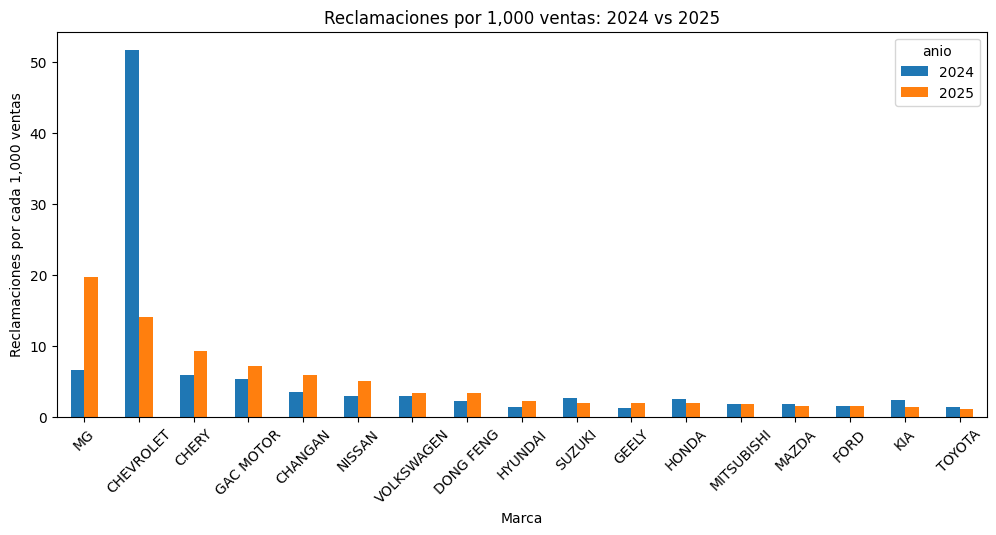

In [46]:
marcas_dos_anios = (
    dataset_integrado
    .groupby("marca_std")["anio"]
    .nunique()
)

marcas_dos_anios = marcas_dos_anios[
    marcas_dos_anios == 2
].index

comparacion_dos_anios = (
    dataset_integrado[
        dataset_integrado["marca_std"].isin(marcas_dos_anios)
    ]
    .pivot(
        index="marca_std",
        columns="anio",
        values="reclamos_por_1000_ventas"
    )
    .sort_values(2025, ascending=False)
)

display(comparacion_dos_anios.round(2))

comparacion_dos_anios.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Reclamaciones por 1,000 ventas: 2024 vs 2025")
plt.xlabel("Marca")
plt.ylabel("Reclamaciones por cada 1,000 ventas")
plt.xticks(rotation=45)
plt.show()


### Lo que vemos

Una misma marca puede subir o bajar de un año a otro.

Por eso el nivel de riesgo lo estamos tratando como **marca-año**, no como una etiqueta permanente de la marca.


# PARTE I — TABLA DESCRIPTIVA

Aquí sacamos los números que usamos en el white paper.


In [47]:
variables_numericas = [
    "ventas",
    "cantidad_quejas",
    "monto_promedio",
    "reclamos_por_1000_ventas"
]

estadisticos = (
    dataset_integrado[variables_numericas]
    .agg(["mean", "median", "min", "max"])
    .T
)

estadisticos["pct_faltantes"] = (
    dataset_integrado[variables_numericas]
    .isna()
    .mean()
    .mul(100)
)

display(estadisticos.round(2))


,mean,median,min,max,pct_faltantes
ventas,2228.55,1173.50,145.00,11507.00,0.0
cantidad_quejas,6.23,4.50,1.00,22.00,0.0
monto_promedio,17966.09,19037.80,269.69,29500.00,0.0
reclamos_por_1000_ventas,5.66,2.94,0.63,51.64,0.0


# Antes del modelo — como vamos a trabajar con nuestras 44 observaciones

ya tenemos definido el conjunto del modelo
son **44 combinaciones marca-año**

sabemos que no es un conjunto grande
pero es el que sale correctamente al unir ACODECO y ADAP

por eso vamos con cuidado

- usamos modelos sencillos
- no hacemos una sola division y ya
- repetimos las pruebas
- comparamos con una referencia basica
- miramos Accuracy y tambien F1 macro

aqui ya no estamos viendo si las 44 sirven o no
**estas 44 son las observaciones del modelo**

lo que queremos ver ahora es cuanto podemos aprender con ellas


# PARTE J — Primer avance del modelo

nuestro dataset para esta parte tiene **44 observaciones marca-año**

con esas 44 filas hacemos un primer avance del modelo de clasificacion

todavia no lo llamamos modelo final
porque queremos seguir revisando variables y resultados

### Algo que tenemos que cuidar

`Nivel_Riesgo_Relativo` se construyo usando

- `cantidad_quejas`
- `ventas`
- `reclamos_por_1000_ventas`

por eso esas tres no las usamos como entrada del modelo

si las usamos seria casi como darle la respuesta

entonces usamos otras caracteristicas de las reclamaciones para ver si ayudan a diferenciar Bajo Medio y Alto


## 35. Elegir variables para este primer intento


In [48]:
variables_modelo = [
    "monto_promedio",
    "monto_mediano",
    "pct_garantia",
    "pct_servicio",
    "pct_falta_info",
    "motivos_distintos",
    "anio"
]

X = dataset_integrado[variables_modelo].copy()
y = dataset_integrado["Nivel_Riesgo_Relativo"].astype(str)

print("Filas para el modelo:", len(X))
print("Variables:", variables_modelo)
print("\nDistribución del objetivo:")
display(y.value_counts())


Filas para el modelo: 44
,Variables: ['monto_promedio', 'monto_mediano', 'pct_garantia', 'pct_servicio', 'pct_falta_info', 'motivos_distintos', 'anio']
,
,Distribución del objetivo:


Nivel_Riesgo_Relativo
Bajo     15
Alto     15
Medio    14
Name: count, dtype: int64

### Que estamos usando para el modelo

cada una de las 44 filas tiene informacion resumida de su marca-año

para esta prueba usamos

- **monto promedio** cuanto representan en promedio las reclamaciones
- **monto mediano** otro valor de referencia del monto
- **% garantia** que parte de las reclamaciones es por garantia
- **% servicio** que parte es por incumplimiento de servicio
- **% falta de informacion** cuanto aparece ese motivo
- **motivos distintos** cuantos tipos de problemas aparecen
- **año** para diferenciar 2024 y 2025

no usamos ventas ni cantidad de reclamaciones como entrada
porque esas ya participaron en la creacion del nivel de riesgo


## 36. Como validamos un modelo con 44 observaciones

con 44 filas no queremos hacer una sola separacion de entrenamiento y prueba y quedarnos con ese resultado

porque dependiendo de cuales marcas-año queden en cada lado el resultado puede cambiar bastante

por eso dividimos el conjunto en 4 partes

en cada vuelta usamos 3 partes para entrenar
y 1 parte para validar

repetimos hasta que todas hayan pasado por validacion

asi usamos mejor las 44 observaciones


In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)


## 36.1 Antes de probar modelos que queremos comprobar

ya tenemos las 44 observaciones
el objetivo Bajo Medio y Alto
y varias caracteristicas de las reclamaciones

ahora queremos ver algo simple

**si esas caracteristicas realmente ayudan a separar Bajo Medio y Alto**

todavia no estamos buscando el modelo perfecto

primero queremos ver si los datos tienen algo que aprender


## 36.2 Que significa la referencia basica

antes de probar modelos necesitamos un punto de comparacion

la referencia basica casi no aprende nada

nos sirve para ver mas o menos que pasaria si hicieramos una prediccion muy simple

despues comparamos los otros modelos contra eso

si un modelo no supera esa referencia entonces realmente no esta aportando mucho


## 37. Crear una referencia básica


In [50]:
modelo_base = DummyClassifier(
    strategy="most_frequent"
)

pred_base = cross_val_predict(
    modelo_base,
    X,
    y,
    cv=cv
)

accuracy_base = accuracy_score(y, pred_base)
f1_base = f1_score(y, pred_base, average="macro")

print("Accuracy modelo base:", round(accuracy_base, 3))
print("F1 macro modelo base:", round(f1_base, 3))


Accuracy modelo base: 0.318
,F1 macro modelo base: 0.23


### ¿Para qué hacemos esto?

El modelo base casi no aprende nada. Nos sirve como punto de comparación.

Si nuestro modelo real no logra mejorar claramente esta referencia, entonces todavía no tenemos un modelo útil.


## 37.1 Por que probamos Regresion Logistica

aunque diga regresion aqui la usamos para clasificar

la probamos primero porque es sencilla
funciona bien como punto de partida
y con pocos datos puede ser mas estable que algo muy complejo

tambien es mas facil de explicar despues

con nuestras 44 observaciones nos parecio una buena primera opcion


## 38. Probar Regresión Logística


In [51]:
modelo_logistico = Pipeline([
    ("escala", StandardScaler()),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

pred_logistico = cross_val_predict(
    modelo_logistico,
    X,
    y,
    cv=cv
)

accuracy_logistico = accuracy_score(
    y,
    pred_logistico
)

f1_logistico = f1_score(
    y,
    pred_logistico,
    average="macro"
)

print("Accuracy:", round(accuracy_logistico, 3))
print("F1 macro:", round(f1_logistico, 3))


Accuracy: 0.5
,F1 macro: 0.497


## 38.1 Por que probamos un Arbol de Decision

el arbol trabaja diferente

va haciendo preguntas sobre las variables
por ejemplo si el porcentaje de garantia es mayor o menor que cierto valor

y con eso va separando los casos

lo dejamos pequeño porque solo tenemos 44 observaciones

si lo dejamos crecer mucho puede aprenderse casi de memoria los pocos casos que tenemos


## 39. Probar un árbol pequeño


In [52]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

pred_arbol = cross_val_predict(
    modelo_arbol,
    X,
    y,
    cv=cv
)

accuracy_arbol = accuracy_score(
    y,
    pred_arbol
)

f1_arbol = f1_score(
    y,
    pred_arbol,
    average="macro"
)

print("Accuracy:", round(accuracy_arbol, 3))
print("F1 macro:", round(f1_arbol, 3))


Accuracy: 0.409
,F1 macro: 0.41


## 40. Comparar los primeros resultados


In [53]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Referencia básica",
        "Regresión logística",
        "Árbol pequeño"
    ],
    "Accuracy": [
        accuracy_base,
        accuracy_logistico,
        accuracy_arbol
    ],
    "F1_macro": [
        f1_base,
        f1_logistico,
        f1_arbol
    ]
})

display(
    comparacion_modelos
    .sort_values("F1_macro", ascending=False)
    .round(3)
)


,Modelo,Accuracy,F1_macro
1,Regresión logística,0.500,0.497
2,Árbol pequeño,0.409,0.410
0,Referencia básica,0.318,0.230


### Lo que encontramos en esta primera prueba

La regresión logística mejora la referencia básica.

Eso nos indica que las variables que armamos a partir de las 44 combinaciones marca-año sí parecen tener algo de información para diferenciar los niveles de riesgo.

Pero también vemos que el resultado todavía no es muy alto.

Eso tiene sentido porque estamos trabajando con pocas observaciones y con variables bastante resumidas.

Por ahora no buscamos decir que el modelo ya está listo.

Lo que sí podemos decir es que ya tenemos:

- un dataset definido;
- una variable objetivo;
- variables de entrada que no repiten directamente la fórmula del riesgo;
- y un modelo que empieza a aprender algo mejor que una referencia básica.


## 40.1 Repetir la prueba varias veces

Con tan pocas filas, una sola partición puede hacernos ver el modelo mejor o peor de lo que realmente es.

Entonces repetimos la validación varias veces y miramos el promedio.

Esto nos da una idea más estable del avance.


In [54]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

cv_repetido = RepeatedStratifiedKFold(
    n_splits=4,
    n_repeats=20,
    random_state=42
)

modelos_repetidos = {
    "Referencia básica": modelo_base,
    "Regresión logística": modelo_logistico,
    "Árbol pequeño": modelo_arbol
}

resultados_repetidos = []

for nombre, modelo in modelos_repetidos.items():

    resultado = cross_validate(
        modelo,
        X,
        y,
        cv=cv_repetido,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro"
        }
    )

    resultados_repetidos.append({
        "Modelo": nombre,
        "Accuracy promedio": resultado["test_accuracy"].mean(),
        "Accuracy variación": resultado["test_accuracy"].std(),
        "F1 promedio": resultado["test_f1_macro"].mean(),
        "F1 variación": resultado["test_f1_macro"].std()
    })

estabilidad_modelos = pd.DataFrame(resultados_repetidos)

display(
    estabilidad_modelos
    .sort_values("F1 promedio", ascending=False)
    .round(3)
)


,Modelo,Accuracy promedio,Accuracy variación,F1 promedio,F1 variación
1,Regresión logística,0.451,0.113,0.435,0.121
2,Árbol pequeño,0.419,0.146,0.402,0.154
0,Referencia básica,0.318,0.045,0.160,0.017


### Lo que vemos

Cuando repetimos la prueba, la regresión logística sigue superando la referencia básica, pero el resultado cambia entre particiones.

Eso era esperable con 44 observaciones.

Por ahora la lectura correcta es:

> hay una señal inicial que vale la pena seguir estudiando, pero todavía no tenemos suficientes datos para hablar de un desempeño definitivo.

Este resultado nos sirve como **avance del modelo**, no como conclusión final.


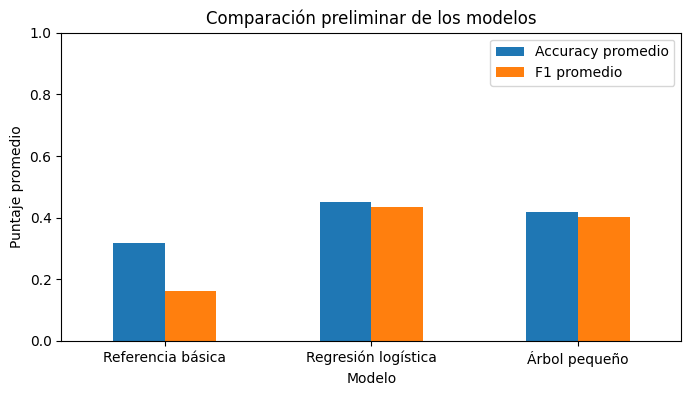

In [55]:
(
    estabilidad_modelos
    .set_index("Modelo")[["Accuracy promedio", "F1 promedio"]]
    .plot(
        kind="bar",
        figsize=(8, 4)
    )
)

plt.title("Comparación preliminar de los modelos")
plt.ylabel("Puntaje promedio")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()


## 40.1 Por que tambien probamos Random Forest

despues quisimos probar algo un poco mas complejo

Random Forest usa varios arboles y combina los resultados

queriamos ver si al hacer eso encontraba algo que los otros modelos no estaban viendo

pero no asumimos que por ser mas complejo iba a ser mejor

con pocos datos puede pasar justamente lo contrario


## 40.2 Probar un modelo adicional: Random Forest

No lo usamos porque sea "mejor" de antemano.

Lo probamos solamente para comparar si un modelo que aprende relaciones un poco más flexibles mejora o no respecto a los modelos sencillos.


In [56]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

pred_rf = cross_val_predict(
    modelo_rf,
    X,
    y,
    cv=cv
)

accuracy_rf = accuracy_score(y, pred_rf)
f1_rf = f1_score(y, pred_rf, average="macro")

print("Accuracy:", round(accuracy_rf, 3))
print("F1 macro:", round(f1_rf, 3))


Accuracy: 0.364
,F1 macro: 0.343


### Qué estamos mirando

No queremos escoger un modelo por un solo número.

Lo que buscamos en este avance es ver si varios modelos consiguen aprender algo mejor que la referencia básica.

Si todos quedan cerca de la referencia, probablemente las variables todavía no aportan suficiente información.


### Que encontramos en esta primera comparacion

en la primera prueba salio mas o menos esto

- referencia basica Accuracy 31.8% y F1 0.230
- Regresion Logistica Accuracy 50.0% y F1 0.497
- Arbol pequeño Accuracy 40.9% y F1 0.410
- Random Forest Accuracy 36.4% y F1 0.343

lo primero que vimos fue que la **Regresion Logistica supera bastante la referencia basica**

tambien queda por encima del arbol y del Random Forest en esta prueba

eso nos llamo la atencion porque el modelo mas sencillo termino funcionando mejor

con pocos datos eso puede pasar
algo mas simple puede agarrar mejor el patron general sin tratar de aprenderse cada caso


In [57]:
comparacion_modelos_4 = pd.DataFrame({
    "Modelo": [
        "Referencia básica",
        "Regresión logística",
        "Árbol pequeño",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_base,
        accuracy_logistico,
        accuracy_arbol,
        accuracy_rf
    ],
    "F1_macro": [
        f1_base,
        f1_logistico,
        f1_arbol,
        f1_rf
    ]
})

display(
    comparacion_modelos_4
    .sort_values("F1_macro", ascending=False)
    .round(3)
)


,Modelo,Accuracy,F1_macro
1,Regresión logística,0.500,0.497
2,Árbol pequeño,0.409,0.410
3,Random Forest,0.364,0.343
0,Referencia básica,0.318,0.230


## 40.2 Por que miramos Accuracy y F1 macro

no queremos mirar un solo numero

**Accuracy** nos dice cuantos casos se clasificaron bien en general

pero como tenemos Bajo Medio y Alto
tambien usamos **F1 macro**

eso nos ayuda a ver el comportamiento en las tres categorias
y no solo en una


## 40.3 Repetir también la comparación con los cuatro modelos

Como seguimos teniendo solo 44 filas, repetimos la validación varias veces.

La idea es no quedarnos con un resultado que dependa demasiado de una sola división.


In [58]:
modelos_repetidos_4 = {
    "Referencia básica": modelo_base,
    "Regresión logística": modelo_logistico,
    "Árbol pequeño": modelo_arbol,
    "Random Forest": modelo_rf
}

resultados_repetidos_4 = []

for nombre, modelo in modelos_repetidos_4.items():

    resultado = cross_validate(
        modelo,
        X,
        y,
        cv=cv_repetido,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro"
        }
    )

    resultados_repetidos_4.append({
        "Modelo": nombre,
        "Accuracy promedio": resultado["test_accuracy"].mean(),
        "Accuracy variación": resultado["test_accuracy"].std(),
        "F1 promedio": resultado["test_f1_macro"].mean(),
        "F1 variación": resultado["test_f1_macro"].std()
    })

estabilidad_modelos_4 = pd.DataFrame(resultados_repetidos_4)

display(
    estabilidad_modelos_4
    .sort_values("F1 promedio", ascending=False)
    .round(3)
)


,Modelo,Accuracy promedio,Accuracy variación,F1 promedio,F1 variación
1,Regresión logística,0.451,0.113,0.435,0.121
2,Árbol pequeño,0.419,0.146,0.402,0.154
3,Random Forest,0.386,0.113,0.364,0.118
0,Referencia básica,0.318,0.045,0.160,0.017


### Cómo interpretamos esta parte

El promedio nos dice cómo se comporta el modelo en varias divisiones distintas.

La columna de variación también importa:

si la variación es grande, significa que el resultado cambia bastante dependiendo de qué filas caen en entrenamiento y cuáles en validación.

Con 44 observaciones esto es algo que esperamos ver.

Por eso esta parte sigue siendo un **avance del modelo**, no el resultado final.


### Que descubrimos cuando repetimos las pruebas

cuando repetimos la validacion varias veces los resultados bajan un poco

y eso en realidad nos ayuda porque nos da una idea mas real de lo que pasa con solo 44 observaciones

la Regresion Logistica sigue quedando mejor en promedio

- Accuracy promedio cerca de **45%**
- F1 macro promedio cerca de **0.44**

el Arbol queda un poco por debajo
y Random Forest tampoco mejora a la Regresion Logistica

lo que entendemos hasta aqui es

1. si hay algo de señal en las variables porque los modelos superan la referencia basica
2. todavia hay bastante variacion porque tenemos pocas observaciones

por eso no lo vemos como resultado final todavia


## 40.4 Por cual modelo vamos encaminados

por ahora vamos con **Regresion Logistica** como modelo principal

no porque ya sea definitivo
sino porque hasta ahora

- dio el mejor resultado en la primera prueba
- tambien se mantiene mejor cuando repetimos la validacion
- supera la referencia basica
- supera al Arbol y al Random Forest
- es mas sencillo de explicar
- y parece funcionar mejor con el tamaño de datos que tenemos

algo que nos quedo claro es que hacer el modelo mas complejo no mejoro el resultado

por ahora preferimos seguir trabajando con Regresion Logistica

despues podemos revisar que variables ayudan mas
y ver si logramos mejorar sin cambiar la forma correcta en que armamos las 44 observaciones


## 41. Ver dónde se equivoca la regresión logística


In [59]:
orden = ["Bajo", "Medio", "Alto"]

matriz = confusion_matrix(
    y,
    pred_logistico,
    labels=orden
)

matriz_df = pd.DataFrame(
    matriz,
    index=[f"Real {x}" for x in orden],
    columns=[f"Predicho {x}" for x in orden]
)

display(matriz_df)

print(
    classification_report(
        y,
        pred_logistico,
        labels=orden,
        zero_division=0
    )
)


,Predicho Bajo,Predicho Medio,Predicho Alto
Real Bajo,7,4,4
Real Medio,4,6,4
Real Alto,3,3,9


              precision    recall  f1-score   support
,
,        Bajo       0.50      0.47      0.48        15
,       Medio       0.46      0.43      0.44        14
,        Alto       0.53      0.60      0.56        15
,
,    accuracy                           0.50        44
,   macro avg       0.50      0.50      0.50        44
,weighted avg       0.50      0.50      0.50        44
,


### Lectura rápida

La prueba no busca demostrar que el modelo ya funciona perfecto.

Nos interesa comprobar que:

- puede diferenciar algo entre Bajo, Medio y Alto;
- no depende de ventas, reclamaciones o la tasa usada para construir el objetivo;
- todavía necesita más observaciones antes de hablar de un desempeño final.


## 41.1 Que podemos decir del modelo hasta ahora

ya tenemos el flujo completo

1. partimos de las reclamaciones
2. las ponemos al mismo nivel que las ventas
3. llegamos a las 44 combinaciones marca-año
4. creamos el nivel de riesgo
5. armamos variables que no repiten la formula del riesgo
6. probamos varios modelos
7. comparamos resultados
8. repetimos la validacion

hasta ahora la **Regresion Logistica es por donde vamos**

la escogemos porque ha sido la que mejor se ha comportado tanto en la primera prueba como en las pruebas repetidas

eso no quiere decir que el modelo este terminado

todavia podemos revisar variables
hacer pequeños cambios
volver a probar
y ver si realmente mejora

si mas adelante otro modelo supera de forma clara a la Regresion Logistica podemos cambiar

por ahora es la opcion que mas sentido nos hace con estos datos


# PARTE K — Primera fase de entrenamiento un poco mas completa

hasta aqui ya probamos varios modelos

ahora queremos mirar un poco mejor lo que esta pasando con la Regresion Logistica
porque por ahora es la que mejor se ha comportado

la idea no es complicar el proyecto
es entender mejor el modelo antes de seguir cambiando cosas


## 42. Revisar si tenemos datos faltantes en las variables del modelo

antes de seguir entrenando queremos confirmar que las 44 filas tienen datos para las variables que estamos usando


In [60]:
revision_modelo = pd.DataFrame({
    "faltantes": X.isnull().sum(),
    "porcentaje": (X.isnull().mean() * 100).round(2)
})

display(revision_modelo)


,faltantes,porcentaje
monto_promedio,0,0.0
monto_mediano,0,0.0
pct_garantia,0,0.0
pct_servicio,0,0.0
pct_falta_info,0,0.0
motivos_distintos,0,0.0
anio,0,0.0


### Lo que vemos

si alguna variable tuviera faltantes tendriamos que decidir como tratarla antes de seguir

si todo esta en cero podemos continuar con las 44 observaciones sin eliminar mas filas


## 43. Revisar si algunas variables estan diciendo casi lo mismo

antes de seguir quisimos mirar la relacion entre las variables numericas

esto nos sirve porque por ejemplo monto promedio y monto mediano pueden parecerse bastante

si dos variables terminan siendo casi iguales despues podemos probar si realmente necesitamos las dos


,monto_promedio,monto_mediano,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos,anio
monto_promedio,1.00,0.94,0.38,-0.28,-0.17,-0.17,0.12
monto_mediano,0.94,1.00,0.34,-0.27,-0.11,-0.10,0.18
pct_garantia,0.38,0.34,1.00,-0.79,-0.39,-0.40,-0.29
pct_servicio,-0.28,-0.27,-0.79,1.00,-0.18,0.03,0.14
pct_falta_info,-0.17,-0.11,-0.39,-0.18,1.00,0.31,0.27
motivos_distintos,-0.17,-0.10,-0.40,0.03,0.31,1.00,0.23
anio,0.12,0.18,-0.29,0.14,0.27,0.23,1.00


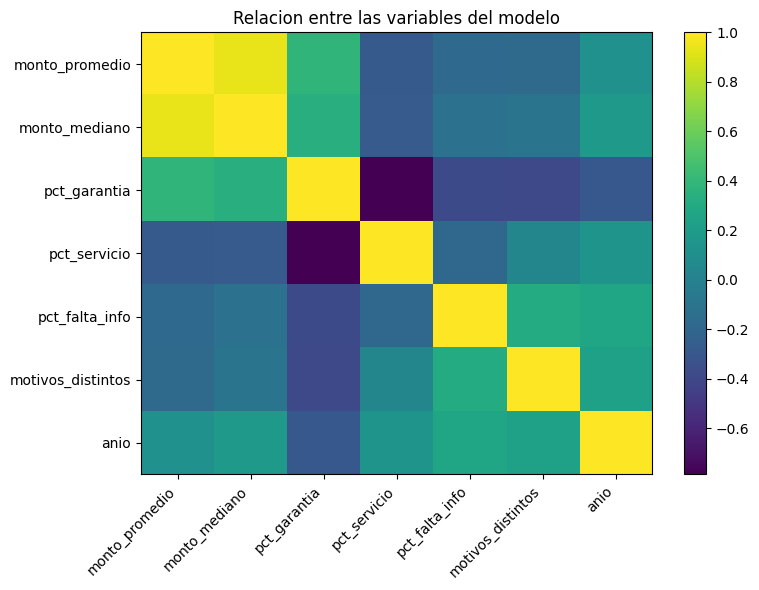

In [61]:
correlaciones = X.corr(numeric_only=True)

display(correlaciones.round(2))

plt.figure(figsize=(8, 6))
plt.imshow(correlaciones, aspect="auto")
plt.xticks(
    range(len(correlaciones.columns)),
    correlaciones.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlaciones.index)),
    correlaciones.index
)
plt.title("Relacion entre las variables del modelo")
plt.colorbar()
plt.tight_layout()
plt.show()


### Que buscamos aqui

no estamos eliminando variables automaticamente

solo queremos ver si hay algunas que se parecen mucho
y despues probar si quitar una ayuda o empeora el modelo


## 44. Ver como cambian las variables segun Bajo Medio y Alto

tambien quisimos ver los promedios de las variables dentro de cada nivel

esto no entrena nada todavia
solo nos ayuda a ver si hay diferencias visibles entre los grupos


In [62]:
resumen_por_riesgo = (
    dataset_integrado
    .groupby("Nivel_Riesgo_Relativo", observed=False)[variables_modelo]
    .mean()
    .round(2)
)

display(resumen_por_riesgo)


,monto_promedio,monto_mediano,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos,anio
Nivel_Riesgo_Relativo,,,,,,,
Bajo,15681.61,16381.99,74.42,12.89,8.89,2.07,2024.47
Medio,18774.69,19927.50,90.24,3.17,3.03,1.79,2024.36
Alto,19495.89,20279.89,86.34,8.92,2.39,1.67,2024.73


### Por que miramos esto

si una variable tiene valores parecidos en Bajo Medio y Alto
puede que no ayude mucho a separar las clases

si vemos diferencias mas claras
puede ser una señal de que esa variable aporta algo


## 45. Entrenar una copia de la Regresion Logistica con las 44 filas

la evaluacion del modelo la seguimos haciendo con validacion cruzada

pero para revisar que esta aprendiendo hacemos una copia del modelo
y la entrenamos con las 44 filas completas

esto es solo para interpretar
no usamos este entrenamiento para decir que tan bueno es el modelo


In [63]:
from sklearn.base import clone

modelo_logistico_interpretar = clone(modelo_logistico)
modelo_logistico_interpretar.fit(X, y)

print("Clases del modelo:")
print(modelo_logistico_interpretar.named_steps["modelo"].classes_)


Clases del modelo:
,['Alto' 'Bajo' 'Medio']


## 46. Ver que variables esta usando mas la Regresion Logistica

como las variables se estandarizan antes de entrar al modelo
podemos mirar los coeficientes para tener una idea de cuales estan pesando mas en cada clase

un valor positivo empuja mas hacia esa clase
y uno negativo va en sentido contrario

no lo tomamos como una verdad absoluta
solo como una forma de entender mejor lo que esta viendo el modelo


In [64]:
clases = modelo_logistico_interpretar.named_steps["modelo"].classes_
coeficientes = modelo_logistico_interpretar.named_steps["modelo"].coef_

tabla_coeficientes = pd.DataFrame(
    coeficientes,
    columns=variables_modelo,
    index=clases
)

display(tabla_coeficientes.round(3))


,monto_promedio,monto_mediano,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos,anio
Alto,0.163,-0.058,0.110,0.145,-0.272,-0.279,0.601
Bajo,-0.034,-0.131,-0.244,0.215,0.359,0.122,-0.312
Medio,-0.129,0.189,0.134,-0.360,-0.087,0.157,-0.290


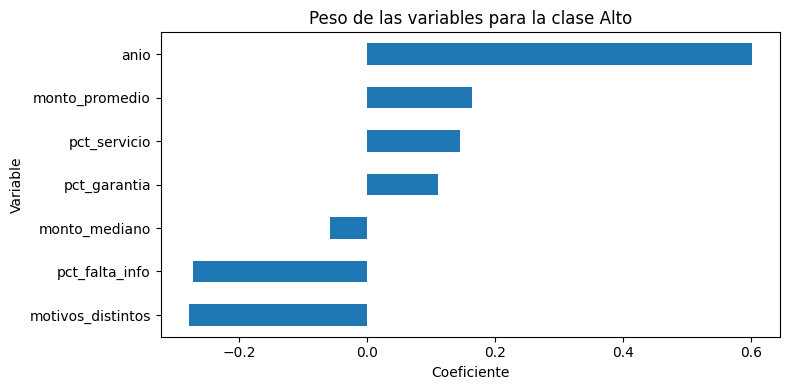

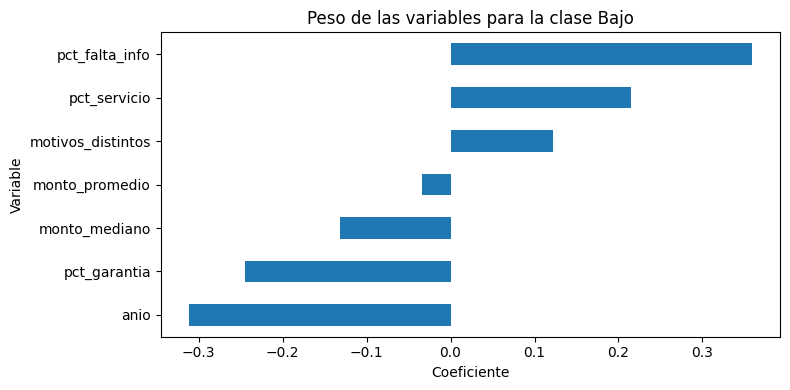

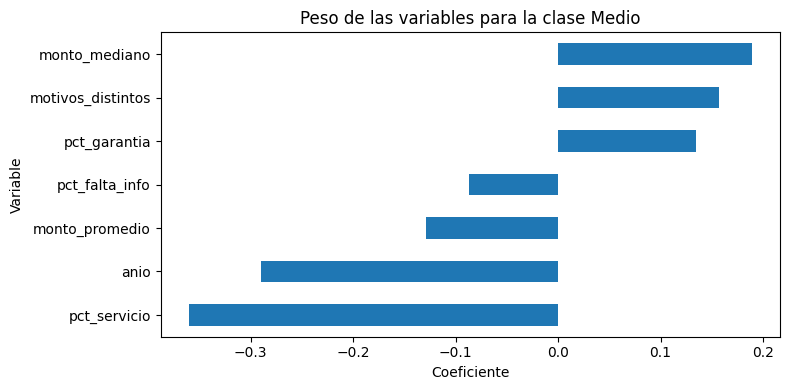

In [65]:
for clase in clases:
    serie = tabla_coeficientes.loc[clase].sort_values()

    plt.figure(figsize=(8, 4))
    serie.plot(kind="barh")
    plt.title(f"Peso de las variables para la clase {clase}")
    plt.xlabel("Coeficiente")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()


### Que queremos entender con esto

queremos ver si por ejemplo el monto
los motivos
o los porcentajes de garantia y servicio
son los que mas ayudan a separar las clases

esto nos puede servir despues para decidir si dejamos todas las variables
o si hacemos una version mas sencilla


## 47. Revisar mejor los errores de la Regresion Logistica

ya vimos la matriz de confusion
ahora queremos ver cuales casos concretos quedaron mal clasificados


In [66]:
errores = dataset_integrado[
    [
        "marca_std",
        "anio",
        "Nivel_Riesgo_Relativo",
        "reclamos_por_1000_ventas",
        "monto_promedio",
        "pct_garantia",
        "pct_servicio",
        "pct_falta_info",
        "motivos_distintos"
    ]
].copy()

errores["prediccion"] = pred_logistico
errores["acerto"] = (
    errores["Nivel_Riesgo_Relativo"].astype(str)
    == errores["prediccion"].astype(str)
)

print("Casos correctos:", errores["acerto"].sum())
print("Casos incorrectos:", (~errores["acerto"]).sum())

display(
    errores[
        ~errores["acerto"]
    ].sort_values(
        ["Nivel_Riesgo_Relativo", "marca_std"]
    )
)


Casos correctos: 22
,Casos incorrectos: 22


,marca_std,anio,Nivel_Riesgo_Relativo,reclamos_por_1000_ventas,monto_promedio,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos,prediccion,acerto
0,BMW,2024,Bajo,1.879699,851.340000,100.000000,0.000000,0.000000,1,Medio,False
25,FORD,2025,Bajo,1.520913,19025.610000,50.000000,50.000000,0.000000,2,Alto,False
8,GEELY,2024,Bajo,1.279318,16932.626667,100.000000,0.000000,0.000000,1,Medio,False
27,GEELY,2025,Bajo,1.912046,22475.000000,83.333333,16.666667,0.000000,2,Alto,False
11,ISUZU,2024,Bajo,0.631313,29000.000000,100.000000,0.000000,0.000000,1,Medio,False
14,MAZDA,2024,Bajo,1.857010,23745.000000,100.000000,0.000000,0.000000,1,Medio,False
35,MAZDA,2025,Bajo,1.568627,16063.930000,50.000000,50.000000,0.000000,2,Alto,False
41,TOYOTA,2025,Bajo,1.129747,19636.223846,84.615385,0.000000,0.000000,3,Alto,False
24,DONG FENG,2025,Medio,3.311258,18060.000000,66.666667,0.000000,33.333333,2,Bajo,False
9,HONDA,2024,Medio,2.463054,4216.746667,100.000000,0.000000,0.000000,1,Bajo,False


### Por que revisamos los errores

un Accuracy solo nos dice cuantos acerto

pero viendo los errores podemos saber si se esta confundiendo mas entre Bajo y Medio
o entre Medio y Alto

tambien podemos ver si hay marcas-año que estan cerca de los cortes
y por eso pueden ser mas dificiles


## 48. Ver que tan segura esta cada prediccion

la Regresion Logistica tambien nos puede dar probabilidades

esto nos sirve porque no es lo mismo que el modelo diga

`Medio 52%`

a que diga

`Medio 90%`

en los dos casos la clase final es Medio
pero en el primero estaba mucho mas dudoso


In [67]:
probabilidades = cross_val_predict(
    modelo_logistico,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

clases_prob = sorted(y.unique())

tabla_prob = pd.DataFrame(
    probabilidades,
    columns=[f"prob_{c}" for c in clases_prob]
)

revision_predicciones = dataset_integrado[
    ["marca_std", "anio", "Nivel_Riesgo_Relativo"]
].reset_index(drop=True).copy()

revision_predicciones = pd.concat(
    [revision_predicciones, tabla_prob],
    axis=1
)

revision_predicciones["prediccion"] = pred_logistico
revision_predicciones["confianza"] = probabilidades.max(axis=1)

revision_predicciones["acerto"] = (
    revision_predicciones["Nivel_Riesgo_Relativo"].astype(str)
    == revision_predicciones["prediccion"].astype(str)
)

display(
    revision_predicciones
    .sort_values("confianza")
    .head(15)
    .round(3)
)


,marca_std,anio,Nivel_Riesgo_Relativo,prob_Alto,prob_Bajo,prob_Medio,prediccion,confianza,acerto
37,MITSUBISHI,2025,Bajo,0.321,0.342,0.337,Bajo,0.342,True
38,NISSAN,2025,Medio,0.385,0.314,0.301,Alto,0.385,False
17,NISSAN,2024,Medio,0.235,0.397,0.368,Bajo,0.397,False
31,KAIYI,2025,Alto,0.400,0.276,0.324,Alto,0.400,True
32,KIA,2025,Bajo,0.280,0.416,0.304,Bajo,0.416,True
14,MAZDA,2024,Bajo,0.351,0.221,0.428,Medio,0.428,False
12,JAC,2024,Medio,0.344,0.213,0.443,Medio,0.443,True
4,DONG FENG,2024,Medio,0.285,0.259,0.455,Medio,0.455,True
36,MG,2025,Alto,0.462,0.386,0.152,Alto,0.462,True
15,MG,2024,Alto,0.327,0.201,0.472,Medio,0.472,False


### Lo que buscamos aqui

queremos encontrar los casos donde el modelo esta mas inseguro

esos casos pueden estar cerca de los limites entre Bajo Medio y Alto
o puede que sus variables no se parezcan claramente a una sola clase


## 49. Primera conclusion del entrenamiento

con esta primera fase ya no solo tenemos un Accuracy

ahora tambien podemos ver

- si las variables tienen faltantes
- si algunas variables se parecen mucho
- como cambian las variables entre Bajo Medio y Alto
- que variables esta usando mas la Regresion Logistica
- en que casos se esta equivocando
- y en cuales predicciones esta mas segura o mas dudosa

por ahora seguimos con **Regresion Logistica**

no porque ya terminamos
sino porque es la que hasta ahora mejor se ha comportado
y tambien es la que podemos entender mejor con el tamaño de datos que tenemos

la siguiente prueba que podemos hacer despues
es quitar o cambiar algunas variables y comprobar si realmente mejora
sin empezar a meter modelos mucho mas complicados


# PARTE L — Por que las 44 filas son nuestro dataset del modelo

En este proyecto vamos a trabajar el modelo con las **44 combinaciones marca-año**.

La razón no es que 44 sea un número ideal.

La razón es que es el número correcto que obtenemos cuando ponemos ACODECO y ADAP en la misma unidad.

Teníamos la posibilidad de repetir las ventas anuales en cada reclamación individual y aparentar que teníamos 274 casos.

No hicimos eso porque muchas filas terminarían compartiendo exactamente:

- la misma marca;
- el mismo año;
- las mismas ventas;
- y el mismo nivel de riesgo.

Eso daría la impresión de tener más información de la que realmente tenemos.

Por eso usamos una fila por `marca + año`.

Con estas 44 observaciones vamos a:

- construir el nivel de riesgo;
- preparar las variables;
- entrenar;
- validar;
- comparar modelos;
- y seguir mejorando el análisis.

La limitación queda documentada, pero la unidad del modelo queda definida.


# PARTE M — Que nos queda claro y que falta

## Lo que ya está claro

1. ACODECO 2024 y 2025 se pueden unir.
2. `Vehículo a Motor` tiene 924 reclamaciones.
3. Dentro de las actividades de autos seleccionadas tenemos 840 registros.
4. Para comparar con ventas nuevas usamos `Agencia de autos + Automóvil`, quedando 321 reclamaciones.
5. 298 tienen una marca identificable.
6. 274 logran hacer match con una marca individual de ADAP.
7. La cobertura del match es 85.36% sobre el total comparable.
8. ADAP registra 54,384 ventas en 2024 y 60,233 en 2025.
9. Las 274 reclamaciones se resumen correctamente por `marca + año`.
10. Nuestro dataset para el modelo queda en **44 combinaciones marca-año**.
11. Sobre esas 44 filas calculamos reclamaciones por cada 1,000 ventas.
12. Con ese indicador construimos el nivel de riesgo relativo Bajo, Medio o Alto.
13. Las mismas variables usadas para crear el riesgo no se usan como entrada directa del modelo.
14. Ya tenemos un primer avance de clasificación y varias comparaciones entre modelos.

## Lo que todavía podemos mejorar

- seguir revisando qué variables aportan más;
- probar otros modelos sencillos;
- revisar la estabilidad de los resultados;
- conseguir más años de ventas y reclamaciones si luego tenemos acceso;
- documentar mejor las marcas que aparecen solo en un año.

## En qué punto estamos

El conjunto para modelar ya está definido: **44 observaciones marca-año**.

Lo que sigue mejorando ahora es el modelo, no la unidad de análisis.
